# Healthcare Patient Clustering by Clinical Indicators

**Dataset:** Diabetes Health Indicators Dataset (CDC BRFSS 2015) — Kaggle (`alexteboul/diabetes-health-indicators-dataset`)

**Goal:** Group patients into clinically meaningful risk segments using unsupervised learning, without using the diabetes label during training.

**Pipeline**

```
Dataset
  1. Load Dataset
  2. Understand & Explore Data
  3. Data Preprocessing
  4. Select Clinical Features
  5. Feature Scaling
  6. Apply Three Clustering Algorithms
       K-Means        -> Elbow Method      -> choose k
       Hierarchical   -> Dendrogram        -> choose k
       DBSCAN         -> K-Distance Graph  -> choose eps
  7. Evaluate All Three Models (Silhouette Score)
  8. Compare Models
  9. Select Best Clustering Model
 10. Visualize Clusters
 11. Profile & Interpret Patient Clusters
 12. Final Conclusion
```

## 1. Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 50)
np.random.seed(42)

os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

### Dataset download

The dataset was pulled from Kaggle into `data/`. To re-download it:

```bash
# Option A: Kaggle CLI (needs ~/.kaggle/kaggle.json)
kaggle datasets download -d alexteboul/diabetes-health-indicators-dataset -p data --unzip

# Option B: direct endpoint
curl -L -o data/kaggle_diabetes.zip \
  "https://www.kaggle.com/api/v1/datasets/download/alexteboul/diabetes-health-indicators-dataset"
unzip -o data/kaggle_diabetes.zip -d data
```

We use `diabetes_012_health_indicators_BRFSS2015.csv`, which keeps the 3-level target
(0 = no diabetes, 1 = prediabetes, 2 = diabetes). The target is **held out** from clustering
and used only at the end to check whether the clusters mean anything clinically.

In [2]:
df = pd.read_csv("data/diabetes_012_health_indicators_BRFSS2015.csv")
print("Rows, Columns:", df.shape)
df.head()

Rows, Columns: (253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 2. Understand & Explore Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

Diabetes_012
0.0    84.24
2.0    13.93
1.0     1.83
Name: proportion, dtype: float64


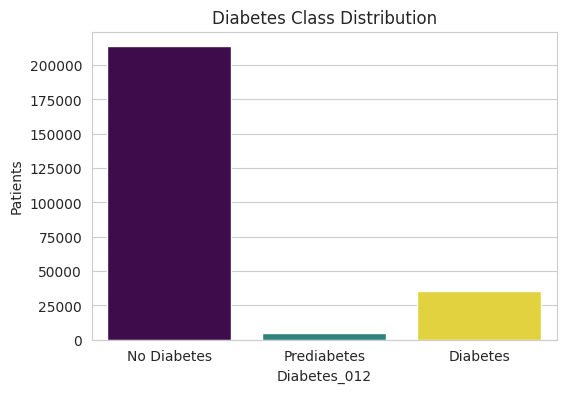

In [5]:
# Target distribution (held out from clustering, used only for validation later)
print(df["Diabetes_012"].value_counts())
print()
print((df["Diabetes_012"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(x="Diabetes_012", data=df, hue="Diabetes_012", palette="viridis", legend=False)
plt.xticks([0, 1, 2], ["No Diabetes", "Prediabetes", "Diabetes"])
plt.title("Diabetes Class Distribution")
plt.ylabel("Patients")
plt.show()

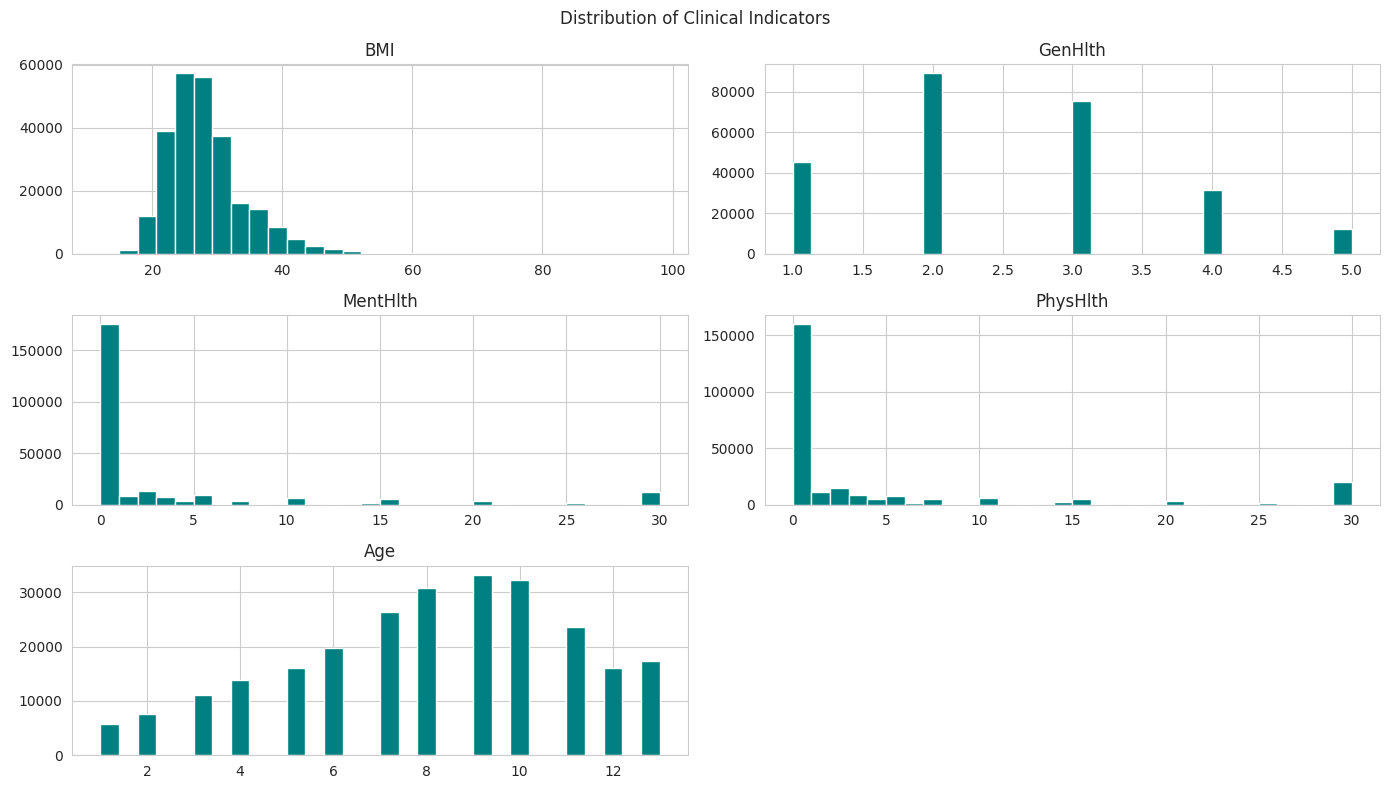

In [6]:
# Distribution of the continuous / ordinal clinical variables
cont_cols = ["BMI", "GenHlth", "MentHlth", "PhysHlth", "Age"]
df[cont_cols].hist(bins=30, figsize=(14, 8), color="teal")
plt.suptitle("Distribution of Clinical Indicators")
plt.tight_layout()
plt.show()

CholCheck               96.27
AnyHealthcare           95.11
Veggies                 81.14
PhysActivity            75.65
Fruits                  63.43
Smoker                  44.32
Sex                     44.03
HighBP                  42.90
HighChol                42.41
DiffWalk                16.82
HeartDiseaseorAttack     9.42
NoDocbcCost              8.42
HvyAlcoholConsump        5.62
Stroke                   4.06
dtype: float64


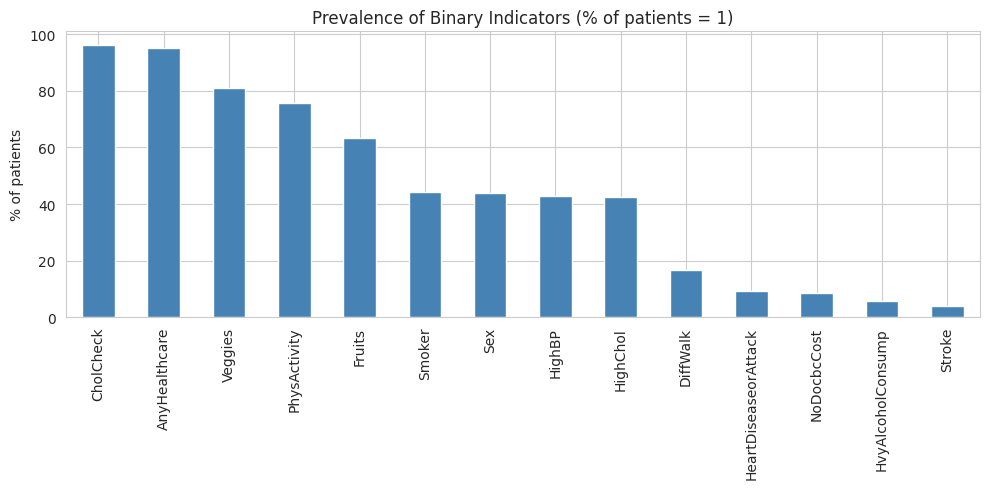

In [7]:
# Prevalence of each binary clinical condition
bin_cols = ["HighBP", "HighChol", "CholCheck", "Smoker", "Stroke", "HeartDiseaseorAttack",
            "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump", "AnyHealthcare",
            "NoDocbcCost", "DiffWalk", "Sex"]

prev = (df[bin_cols].mean() * 100).sort_values(ascending=False)
print(prev.round(2))

plt.figure(figsize=(10, 5))
prev.plot(kind="bar", color="steelblue")
plt.title("Prevalence of Binary Indicators (% of patients = 1)")
plt.ylabel("% of patients")
plt.tight_layout()
plt.show()

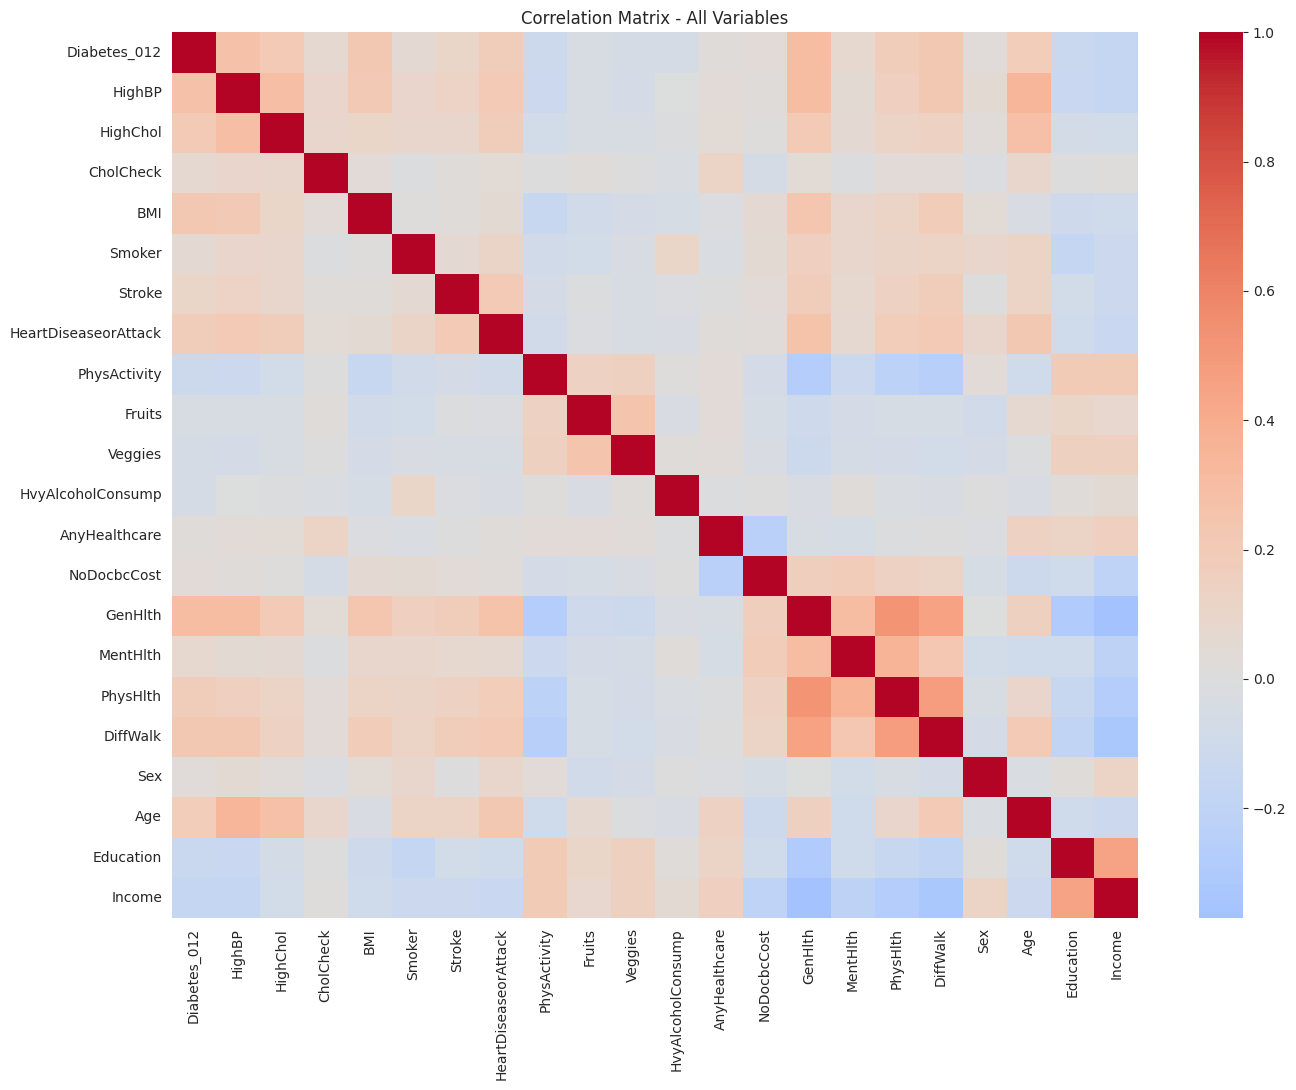

GenHlth                 0.303
HighBP                  0.272
BMI                     0.224
DiffWalk                0.224
HighChol                0.209
Age                     0.185
HeartDiseaseorAttack    0.180
PhysHlth                0.176
Stroke                  0.107
MentHlth                0.074
CholCheck               0.068
Smoker                  0.063
NoDocbcCost             0.035
Sex                     0.031
AnyHealthcare           0.015
Fruits                 -0.042
HvyAlcoholConsump      -0.058
Veggies                -0.059
PhysActivity           -0.122
Education              -0.131
Income                 -0.171
Name: Diabetes_012, dtype: float64


In [8]:
# Correlation heatmap of all variables
plt.figure(figsize=(14, 11))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix - All Variables")
plt.tight_layout()
plt.show()

# Which variables move most with diabetes status?
print(df.corr()["Diabetes_012"].drop("Diabetes_012").sort_values(ascending=False).round(3))

## 3. Data Preprocessing

In [9]:
# 3a. Missing values
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Total missing:", df.isnull().sum().sum())

Missing values per column:
Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Total missing: 0


In [10]:
# 3b. Duplicate rows - identical survey responses bias centroids toward the most common
# answer pattern, so we drop them.
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Duplicate rows: 23899
Shape after dropping duplicates: (229781, 22)


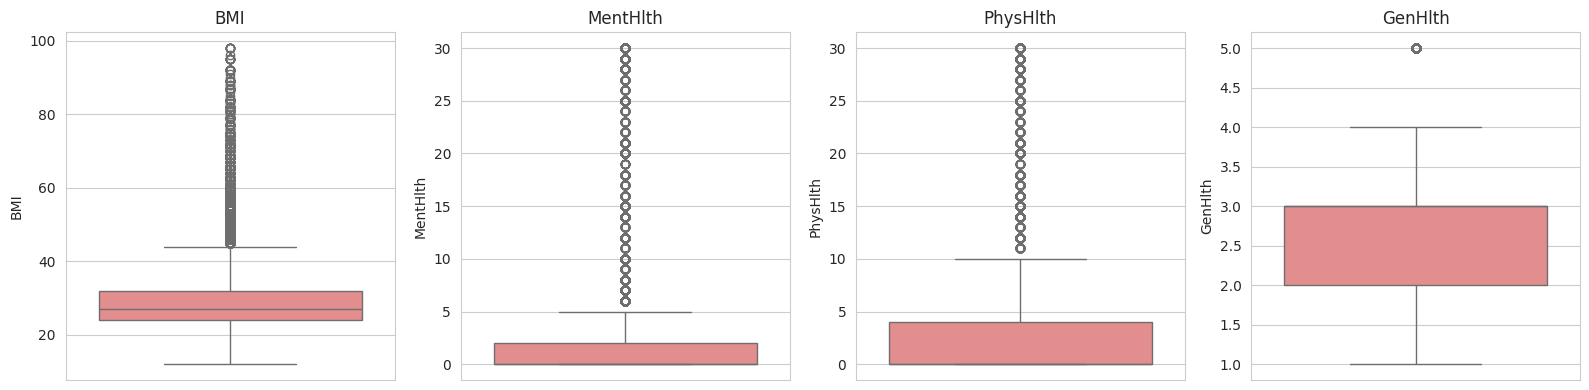

BMI range: 12.0 - 98.0


In [11]:
# 3c. Outlier check on the continuous variables
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ["BMI", "MentHlth", "PhysHlth", "GenHlth"]):
    sns.boxplot(y=df[col], ax=ax, color="lightcoral")
    ax.set_title(col)
plt.tight_layout()
plt.show()

print("BMI range:", df["BMI"].min(), "-", df["BMI"].max())

**Decision on outliers.** A BMI of 60-98 is clinically real (morbid obesity) and is exactly
the high-risk group we want a cluster for, so we do **not** delete those patients. K-Means is
distance-based though, so a few BMI ~ 98 rows would stretch that axis and pull a centroid
toward them. We **cap BMI at the 1st and 99th percentile** instead: the patients stay, the
extreme leverage goes.

`MentHlth` and `PhysHlth` ("days of poor health in last 30") only look outlier-heavy because
most people answer 0. 30 is a valid ceiling, not an error, so we leave them alone.

In [12]:
p01 = df["BMI"].quantile(0.01)
p99 = df["BMI"].quantile(0.99)
df["BMI"] = df["BMI"].clip(lower=p01, upper=p99)

print("BMI capped to:", p01, "-", p99)
print("BMI range now:", df["BMI"].min(), "-", df["BMI"].max())

BMI capped to: 18.0 - 50.0
BMI range now: 18.0 - 50.0


**Sampling.** Hierarchical clustering and DBSCAN both need pairwise distances between all
points — that is O(n^2) memory, around 250 GB for 230k patients. Since step 8 compares the
three algorithms against each other, all three have to run on the *same* data. We therefore
draw a random sample of **10,000 patients** and build the whole project on it.

In [13]:
SAMPLE_SIZE = 10000
df = df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print("Working sample:", df.shape)

Working sample: (10000, 22)


## 4. Select Clinical Features

We cluster on **clinical indicators only**:

| Dropped | Reason |
|---|---|
| `Diabetes_012` | Target — held out, used only to validate the clusters afterwards |
| `Income`, `Education` | Socio-economic, not a clinical measurement |
| `AnyHealthcare`, `NoDocbcCost` | Healthcare *access*, not patient health |
| `Fruits`, `Veggies` | Self-reported diet, near-zero correlation with outcome |
| `CholCheck` | ~96% of patients = 1, almost no variance to cluster on |
| `Sex` | Demographic; would split clusters by gender instead of by risk |
| `HvyAlcoholConsump` | Only ~6% = 1; K-Means carved it into its own cluster, which hides the risk structure we are after |

Everything kept is a diagnosed condition, a biometric, a functional-status measure, or a
behavioural risk factor.

In [14]:
clinical_features = [
    "HighBP",                # diagnosed hypertension
    "HighChol",              # diagnosed high cholesterol
    "BMI",                   # biometric
    "Stroke",                # cardiovascular event history
    "HeartDiseaseorAttack",  # cardiovascular event history
    "GenHlth",               # general health 1=excellent .. 5=poor
    "MentHlth",              # poor mental health days (0-30)
    "PhysHlth",              # poor physical health days (0-30)
    "DiffWalk",              # mobility limitation
    "Age",                   # age bucket 1-13
    "Smoker",                # behavioural risk
    "PhysActivity",          # behavioural protective factor
]

X = df[clinical_features]
print("Feature matrix:", X.shape)
X.describe().T.round(2)

Feature matrix: (10000, 12)


,count,mean,std,min,25%,50%,75%,max
HighBP,10000.0,0.45,0.50,0.0,0.0,0.0,1.0,1.0
HighChol,10000.0,0.44,0.50,0.0,0.0,0.0,1.0,1.0
BMI,10000.0,28.56,6.13,18.0,24.0,27.0,32.0,50.0
Stroke,10000.0,0.04,0.20,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,10000.0,0.10,0.30,0.0,0.0,0.0,0.0,1.0
GenHlth,10000.0,2.59,1.06,1.0,2.0,3.0,3.0,5.0
MentHlth,10000.0,3.55,7.80,0.0,0.0,0.0,2.0,30.0
PhysHlth,10000.0,4.63,9.02,0.0,0.0,0.0,4.0,30.0
DiffWalk,10000.0,0.18,0.39,0.0,0.0,0.0,0.0,1.0
Age,10000.0,8.11,3.09,1.0,6.0,8.0,10.0,13.0


In [15]:
# A near-constant feature adds noise instead of structure - check variance
print(X.var().sort_values().round(3))

Stroke                   0.038
HeartDiseaseorAttack     0.090
DiffWalk                 0.150
PhysActivity             0.193
HighChol                 0.247
HighBP                   0.247
Smoker                   0.249
GenHlth                  1.130
Age                      9.562
BMI                     37.573
MentHlth                60.879
PhysHlth                81.299
dtype: float64


## 5. Feature Scaling

All features are already numeric: the binary flags are 0/1, and `GenHlth`, `Age`, `MentHlth`,
`PhysHlth` are ordinal integers whose order is meaningful (higher = worse / older), so no
one-hot encoding is needed — one-hot would actually destroy that ordering.

Scaling is mandatory: `BMI` spans ~18-50 and `PhysHlth` 0-30, while the binary flags span 0-1.
Without standardizing, Euclidean distance would be decided almost entirely by BMI.

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=clinical_features)
print("Scaled shape:", X_scaled.shape)
print()
print("Mean of each scaled feature (should be ~0):", X_scaled_df.mean().round(4).to_dict())
print()
print("Std of each scaled feature (should be ~1):", X_scaled_df.std().round(4).to_dict())
X_scaled_df.head()

Scaled shape: (10000, 12)

Mean of each scaled feature (should be ~0): {'HighBP': 0.0, 'HighChol': -0.0, 'BMI': -0.0, 'Stroke': -0.0, 'HeartDiseaseorAttack': 0.0, 'GenHlth': 0.0, 'MentHlth': 0.0, 'PhysHlth': 0.0, 'DiffWalk': -0.0, 'Age': -0.0, 'Smoker': 0.0, 'PhysActivity': 0.0}

Std of each scaled feature (should be ~1): {'HighBP': 1.0001, 'HighChol': 1.0001, 'BMI': 1.0001, 'Stroke': 1.0001, 'HeartDiseaseorAttack': 1.0001, 'GenHlth': 1.0001, 'MentHlth': 1.0001, 'PhysHlth': 1.0001, 'DiffWalk': 1.0001, 'Age': 1.0001, 'Smoker': 1.0001, 'PhysActivity': 1.0001}


,HighBP,HighChol,BMI,Stroke,HeartDiseaseorAttack,GenHlth,MentHlth,PhysHlth,DiffWalk,Age,Smoker,PhysActivity
0,-0.897611,1.119267,0.723584,-0.20439,2.990043,0.386691,2.108054,1.815605,2.110814,1.256941,1.079555,0.593673
1,-0.897611,-0.893442,-0.255312,-0.20439,-0.334443,2.268400,3.389764,2.813812,-0.473751,-1.330289,1.079555,-1.684428
2,1.114068,-0.893442,-1.397358,-0.20439,-0.334443,-0.554163,-0.455366,-0.513544,-0.473751,0.933537,-0.926307,0.593673
3,1.114068,-0.893442,-0.092163,-0.20439,-0.334443,-0.554163,-0.455366,-0.513544,-0.473751,1.580345,1.079555,0.593673
4,-0.897611,-0.893442,-1.723656,-0.20439,-0.334443,2.268400,3.389764,2.813812,2.110814,-0.683482,1.079555,-1.684428


## 6. Apply Three Clustering Algorithms

### 6a. K-Means — Elbow Method to choose k

In [17]:
k_range = range(2, 9)
inertia = []
km_sil = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    km_sil.append(silhouette_score(X_scaled, labels))
    print(f"k={k}  inertia={km.inertia_:,.0f}  silhouette={km_sil[-1]:.4f}  "
          f"sizes={np.bincount(labels)}")

k=2  inertia=100,208  silhouette=0.2748  sizes=[7606 2394]


k=3  inertia=90,866  silhouette=0.1418  sizes=[1721 3377 4902]


k=4  inertia=82,279  silhouette=0.1539  sizes=[1636 3159  401 4804]


k=5  inertia=77,385  silhouette=0.1304  sizes=[ 401 2951 2157 1449 3042]


k=6  inertia=72,025  silhouette=0.1310  sizes=[2333 2791 2523 1196  401  756]


k=7  inertia=67,697  silhouette=0.1462  sizes=[1584 1670 1018 2375  401  750 2202]


k=8  inertia=64,373  silhouette=0.1404  sizes=[1376 1895 1068 1934  750 1933  643  401]


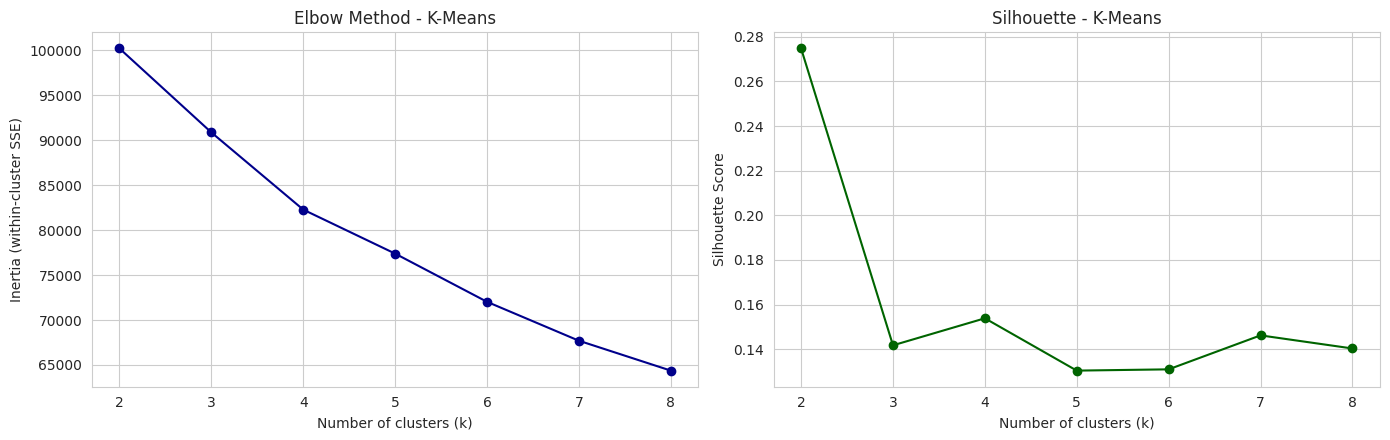

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(list(k_range), inertia, "o-", color="darkblue")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_title("Elbow Method - K-Means")

axes[1].plot(list(k_range), km_sil, "o-", color="darkgreen")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette - K-Means")

for ax in axes:
    ax.grid(True)
plt.tight_layout()
plt.show()

**Reading the elbow.** Inertia drops steeply up to k = 3 and then flattens — the bend is at
k = 3. k = 2 has the higher silhouette, but it only splits the cohort into healthy /
unhealthy with no middle tier, and the middle tier is the group where intervention still
changes the outcome. We take **k = 3**.

In [19]:
BEST_K = 3
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

print("Cluster sizes:", np.bincount(km_labels))
print("Silhouette Score:", round(silhouette_score(X_scaled, km_labels), 4))

Cluster sizes: [1721 3377 4902]


Silhouette Score: 0.1418


### 6b. Hierarchical Clustering — Dendrogram to choose k

Ward linkage merges the two clusters that increase within-cluster variance the least — the
same objective family as K-Means.

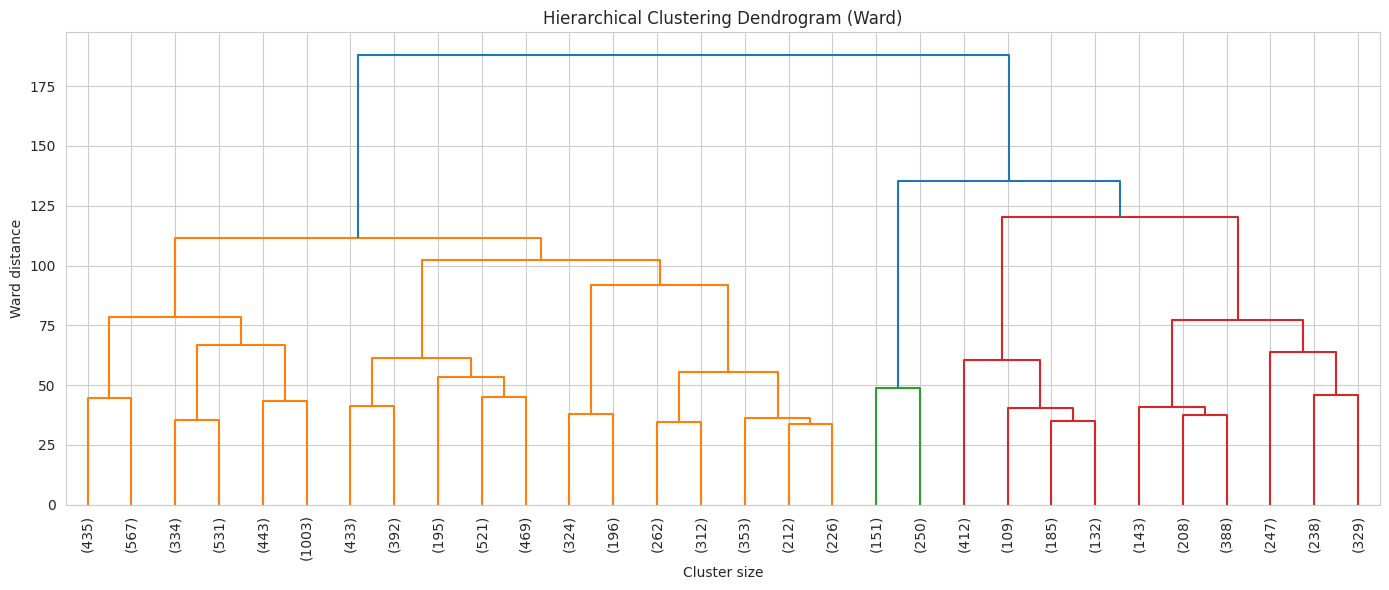

In [20]:
link = linkage(X_scaled, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(link, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Cluster size")
plt.ylabel("Ward distance")
plt.tight_layout()
plt.show()

In [21]:
hc_sil = []
for k in k_range:
    labels_h = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X_scaled)
    hc_sil.append(silhouette_score(X_scaled, labels_h))
    print(f"k={k}  silhouette={hc_sil[-1]:.4f}  sizes={np.bincount(labels_h)}")

k=2  silhouette=0.2495  sizes=[2792 7208]


k=3  silhouette=0.2486  sizes=[2391 7208  401]


k=4  silhouette=0.2557  sizes=[7208 1553  401  838]


k=5  silhouette=0.1236  sizes=[3895 3313  401  838 1553]


k=6  silhouette=0.1300  sizes=[1885 3313 2010  838 1553  401]


k=7  silhouette=0.1470  sizes=[3313 1553 2010  838 1365  401  520]


k=8  silhouette=0.1272  sizes=[1553 2311 2010  838 1365  401  520 1002]


**Reading the dendrogram.** The longest vertical gap before a merge sits just below the top,
where the tree is split into 3 big branches — so we take **k = 3** here too. That also keeps
the comparison in step 8 like-for-like: three algorithms, same data, 3 segments.

In [22]:
hier = AgglomerativeClustering(n_clusters=3, linkage="ward")
hc_labels = hier.fit_predict(X_scaled)

print("Cluster sizes:", np.bincount(hc_labels))
print("Silhouette Score:", round(silhouette_score(X_scaled, hc_labels), 4))

Cluster sizes: [2391 7208  401]


Silhouette Score: 0.2486


### 6c. DBSCAN — K-Distance Graph to choose eps

DBSCAN needs two parameters. `min_samples` is set by the rule of thumb **2 x number of
features** = 24. `eps` is read off the k-distance graph: sort every point by its distance to
its 24th nearest neighbour and look for the knee — points to the left are in dense regions,
points past the knee are outliers.

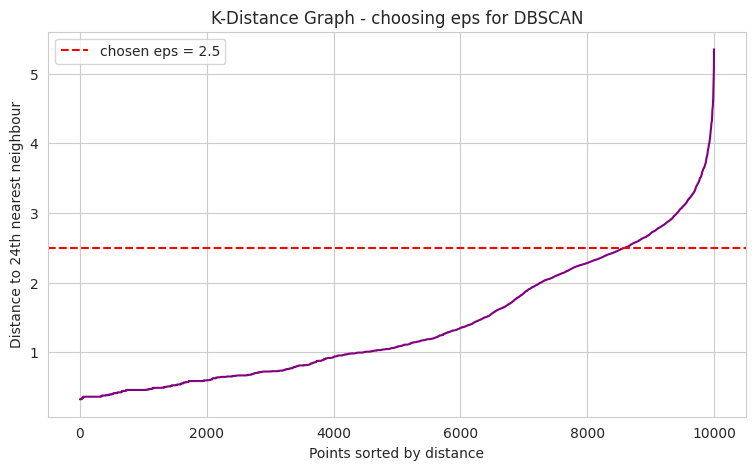

Percentiles of the k-distance curve:
  50th: 1.08
  75th: 2.09
  90th: 2.70
  95th: 3.08
  99th: 3.86


In [23]:
MIN_SAMPLES = 2 * len(clinical_features)

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(k_dist, color="purple")
plt.axhline(2.5, color="red", ls="--", label="chosen eps = 2.5")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {MIN_SAMPLES}th nearest neighbour")
plt.title("K-Distance Graph - choosing eps for DBSCAN")
plt.legend()
plt.grid(True)
plt.show()

print("Percentiles of the k-distance curve:")
for p in [50, 75, 90, 95, 99]:
    print(f"  {p}th: {np.percentile(k_dist, p):.2f}")

In [24]:
# Sanity sweep around the knee before fixing eps
for eps in [1.5, 2.0, 2.5, 3.0, 3.5]:
    labels_d = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(X_scaled)
    n_clusters = len(set(labels_d)) - (1 if -1 in labels_d else 0)
    n_noise = (labels_d == -1).sum()
    sil = silhouette_score(X_scaled, labels_d) if n_clusters > 1 else float("nan")
    biggest = pd.Series(labels_d[labels_d != -1]).value_counts().max() if n_clusters else 0
    print(f"eps={eps}  clusters={n_clusters}  noise={n_noise}  "
          f"largest_cluster={biggest}  silhouette={sil:.4f}")

eps=1.5  clusters=27  noise=2705  largest_cluster=1545  silhouette=0.1271


eps=2.0  clusters=34  noise=1852  largest_cluster=1606  silhouette=0.1540


eps=2.5  clusters=5  noise=566  largest_cluster=7389  silhouette=0.2264


eps=3.0  clusters=5  noise=153  largest_cluster=8739  silhouette=0.2665


eps=3.5  clusters=2  noise=40  largest_cluster=9598  silhouette=0.3775


The curve bends around 2.5. Below it DBSCAN shatters the data into 25+ micro-clusters with
~2,000 noise points; above it everything collapses into one blob. **eps = 2.5** is the knee.

In [25]:
EPS = 2.5
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
db_labels = dbscan.fit_predict(X_scaled)

n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print("Clusters found:", n_db_clusters)
print("Noise points:", n_noise, f"({n_noise / len(db_labels) * 100:.1f}%)")
print("Cluster sizes:")
print(pd.Series(db_labels).value_counts().sort_index())
print()
print("Silhouette Score:", round(silhouette_score(X_scaled, db_labels), 4))

Clusters found: 5
Noise points: 566 (5.7%)
Cluster sizes:
-1     566
 0    7389
 1     130
 2    1233
 3     456
 4     226
Name: count, dtype: int64



Silhouette Score: 0.2264


## 7. Evaluate All Three Models

**Silhouette Score** measures, for every patient, how close it is to its own cluster versus
the nearest other cluster. It runs from -1 to 1 and **higher is better**. All three models
are scored on the exact same 10,000 patients and the same 12 scaled features, so the numbers
are directly comparable.

In [26]:
def describe(name, labels):
    sizes = pd.Series(labels).value_counts().sort_index()
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    return {
        "Algorithm": name,
        "Clusters": n_clusters,
        "Silhouette": round(silhouette_score(X_scaled, labels), 4),
        "Largest cluster %": round(sizes[sizes.index != -1].max() / len(labels) * 100, 1),
        "Smallest cluster": int(sizes[sizes.index != -1].min()),
        "Noise points": int((labels == -1).sum()),
    }

comparison = pd.DataFrame([
    describe("K-Means (k=3)", km_labels),
    describe("Hierarchical (k=3)", hc_labels),
    describe(f"DBSCAN (eps={EPS})", db_labels),
])
comparison

,Algorithm,Clusters,Silhouette,Largest cluster %,Smallest cluster,Noise points
0,K-Means (k=3),3,0.1418,49.0,1721,0
1,Hierarchical (k=3),3,0.2486,72.1,401,0
2,DBSCAN (eps=2.5),5,0.2264,73.9,130,566


## 8. Compare Models

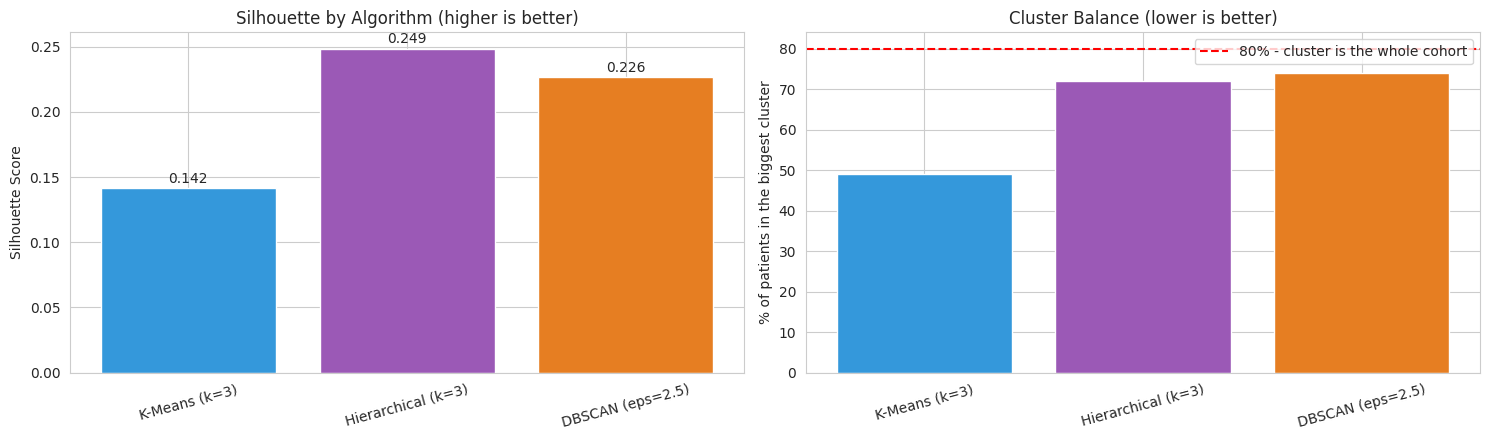

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

axes[0].bar(comparison["Algorithm"], comparison["Silhouette"],
            color=["#3498db", "#9b59b6", "#e67e22"])
axes[0].set_ylabel("Silhouette Score")
axes[0].set_title("Silhouette by Algorithm (higher is better)")
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(comparison["Silhouette"]):
    axes[0].text(i, v + 0.004, f"{v:.3f}", ha="center")

axes[1].bar(comparison["Algorithm"], comparison["Largest cluster %"],
            color=["#3498db", "#9b59b6", "#e67e22"])
axes[1].axhline(80, color="red", ls="--", label="80% - cluster is the whole cohort")
axes[1].set_ylabel("% of patients in the biggest cluster")
axes[1].set_title("Cluster Balance (lower is better)")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend()

plt.tight_layout()
plt.show()

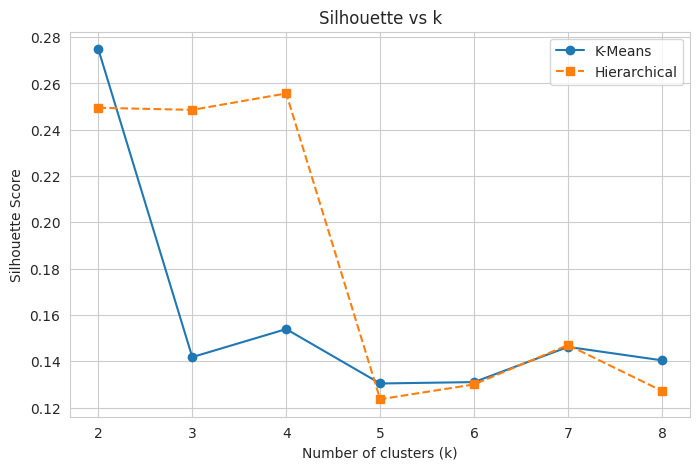

,kmeans_silhouette,hier_silhouette
k,,
2,0.2748,0.2495
3,0.1418,0.2486
4,0.1539,0.2557
5,0.1304,0.1236
6,0.1310,0.1300
7,0.1462,0.1470
8,0.1404,0.1272


In [28]:
# Silhouette across k for the two algorithms that take a k
scores = pd.DataFrame({
    "k": list(k_range),
    "kmeans_silhouette": np.round(km_sil, 4),
    "hier_silhouette": np.round(hc_sil, 4),
}).set_index("k")

plt.figure(figsize=(8, 5))
plt.plot(scores.index, scores["kmeans_silhouette"], "o-", label="K-Means")
plt.plot(scores.index, scores["hier_silhouette"], "s--", label="Hierarchical")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette vs k")
plt.legend()
plt.grid(True)
plt.show()

scores.to_csv("outputs/evaluation_scores.csv")
scores

## 9. Select Best Clustering Model

**Choice: K-Means with k = 3.**

| Algorithm | Silhouette | What the clusters actually look like |
|---|---|---|
| K-Means (k=3) | 0.142 | 17% / 34% / 49% — three usable segments |
| Hierarchical (k=3) | 0.249 | 24% / 72% / 4% — one cluster holds most of the cohort |
| DBSCAN (eps=2.5) | 0.226 | 74% in one cluster, 4 small ones, 566 noise points |

Silhouette alone would pick Hierarchical. The score is misleading here: it rewards a solution
that dumps 72% of patients into one group, which gives a care team nothing to act on. DBSCAN
has the same problem and additionally labels 566 patients as noise — DBSCAN looks for dense
blobs separated by empty space, and health risk is a continuum, so there is no empty space for
it to find.

Two more reasons for K-Means:

- **It can assign new patients.** K-Means leaves behind centroids, so an unseen patient is
  assigned with one distance computation. Hierarchical and DBSCAN produce labels but no model
  — serving them would mean refitting on every new patient. The Streamlit app needs this.
- **All three scores are low (0.14-0.25),** which is normal for mixed binary/ordinal health
  data. No algorithm found well-separated natural groups, so balance and usability decide.

In [29]:
df["Cluster"] = km_labels
final_labels = km_labels

print("Final model: K-Means, k =", BEST_K)
print("Silhouette:", round(silhouette_score(X_scaled, final_labels), 4))
print()
print(df["Cluster"].value_counts().sort_index())
print()
print((df["Cluster"].value_counts(normalize=True).sort_index() * 100).round(2))

Final model: K-Means, k = 3


Silhouette: 0.1418

Cluster
0    1721
1    3377
2    4902
Name: count, dtype: int64

Cluster
0    17.21
1    33.77
2    49.02
Name: proportion, dtype: float64


## 10. Visualize Clusters

Explained variance ratio: [0.2372 0.1216]
Total variance captured: 0.3588


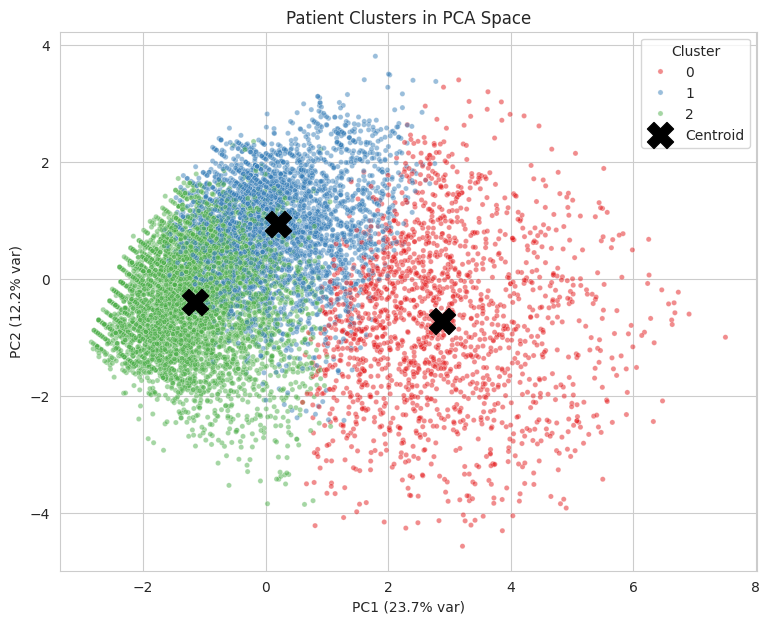

In [30]:
# PCA squeezes the 12 features into 2 so the clusters can be plotted
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_.round(4))
print("Total variance captured:", pca.explained_variance_ratio_.sum().round(4))

centroids = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(9, 7))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=df["Cluster"],
                palette="Set1", s=14, alpha=0.5)
plt.scatter(centroids[:, 0], centroids[:, 1], marker="X", s=350, c="black", label="Centroid")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("Patient Clusters in PCA Space")
plt.legend(title="Cluster")
plt.show()

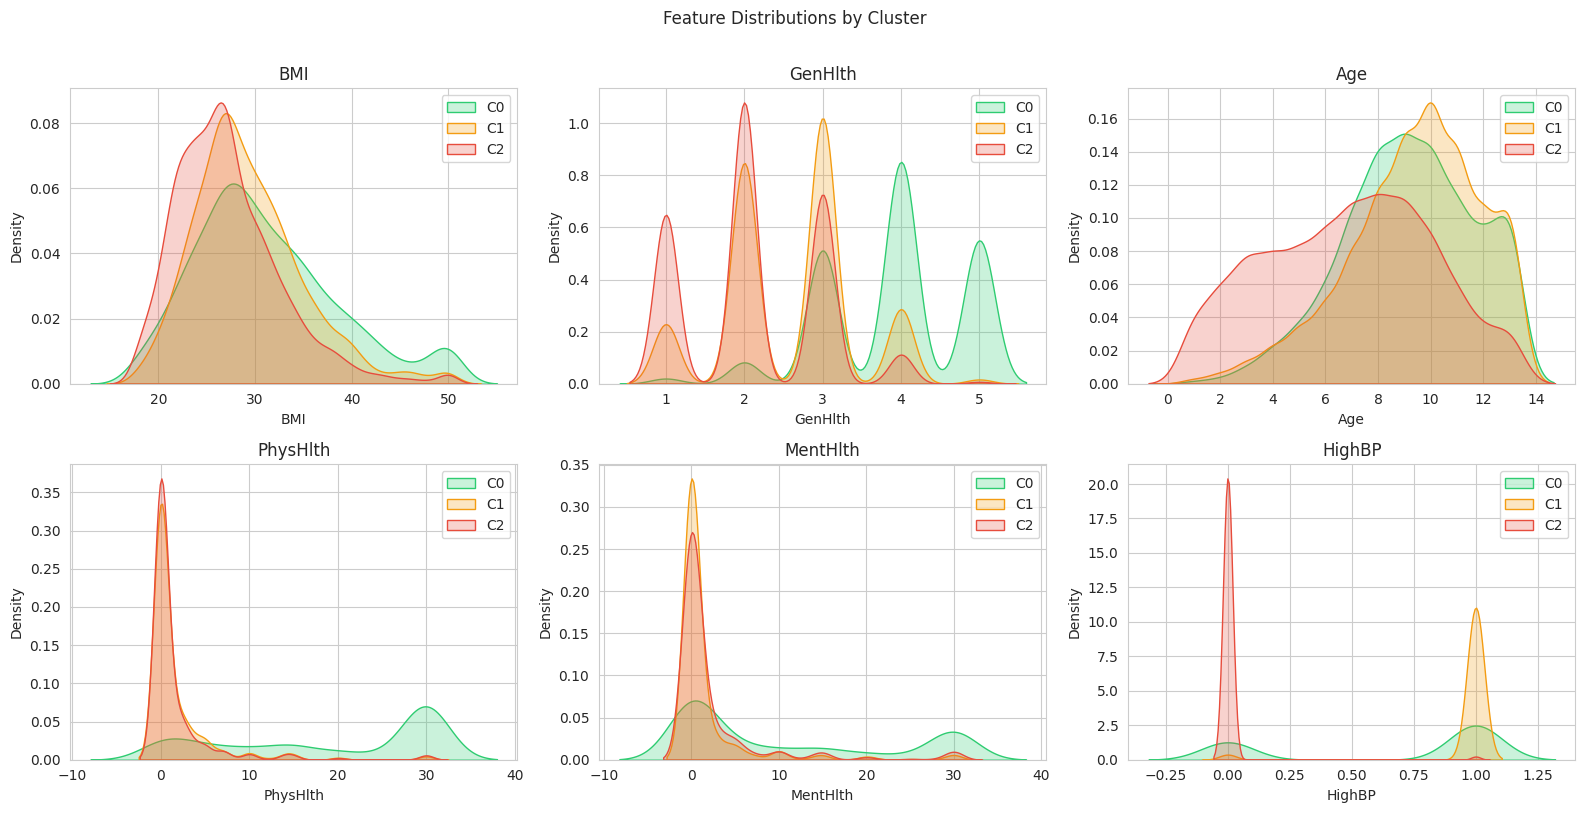

In [31]:
# Where do the clusters actually differ?
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
for ax, col in zip(axes.flatten(), ["BMI", "GenHlth", "Age", "PhysHlth", "MentHlth", "HighBP"]):
    for c in sorted(df["Cluster"].unique()):
        sns.kdeplot(df[df["Cluster"] == c][col], ax=ax, label=f"C{c}",
                    fill=True, alpha=0.25, color=colors[c % 3])
    ax.set_title(col)
    ax.legend()
plt.suptitle("Feature Distributions by Cluster", y=1.01)
plt.tight_layout()
plt.show()

## 11. Profile & Interpret Patient Clusters

In [32]:
# Mean of every clinical feature per cluster, in original units
profile = df.groupby("Cluster")[clinical_features].mean().round(3)
profile["n_patients"] = df["Cluster"].value_counts().sort_index()
profile.to_csv("outputs/cluster_profiles.csv")
profile.T

Cluster,0,1,2
HighBP,0.662,0.967,0.011
HighChol,0.636,0.571,0.289
BMI,31.116,29.312,27.155
Stroke,0.132,0.037,0.010
HeartDiseaseorAttack,0.309,0.114,0.018
GenHlth,3.908,2.589,2.126
MentHlth,10.582,1.654,2.393
PhysHlth,18.818,1.765,1.623
DiffWalk,0.783,0.092,0.036
Age,9.202,9.378,6.860


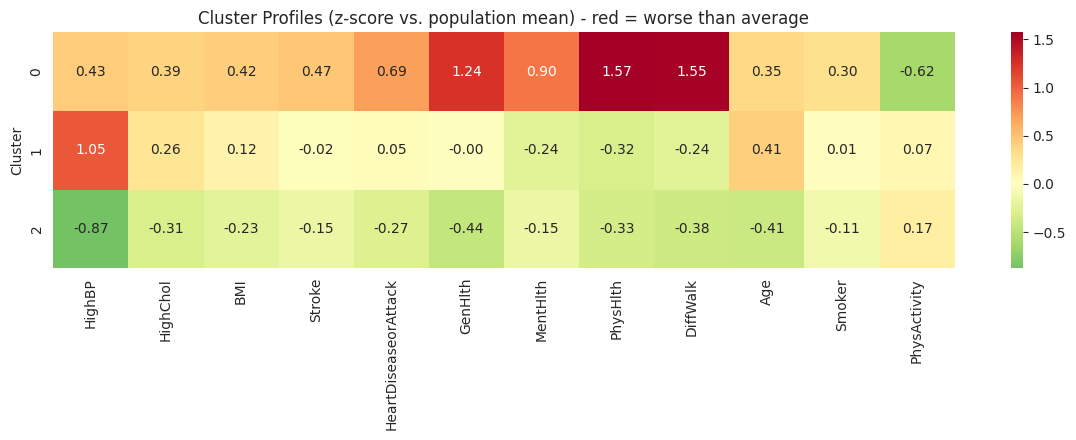

,HighBP,HighChol,BMI,Stroke,HeartDiseaseorAttack,GenHlth,MentHlth,PhysHlth,DiffWalk,Age,Smoker,PhysActivity
Cluster,,,,,,,,,,,,
0,0.43,0.39,0.42,0.47,0.69,1.24,0.90,1.57,1.55,0.35,0.30,-0.62
1,1.05,0.26,0.12,-0.02,0.05,-0.00,-0.24,-0.32,-0.24,0.41,0.01,0.07
2,-0.87,-0.31,-0.23,-0.15,-0.27,-0.44,-0.15,-0.33,-0.38,-0.41,-0.11,0.17


In [33]:
# Same profile as z-scores, so we can see which features define each cluster
profile_z = df.groupby("Cluster")[clinical_features].mean()
profile_z = (profile_z - X.mean()) / X.std()

plt.figure(figsize=(12, 4.5))
sns.heatmap(profile_z, cmap="RdYlGn_r", center=0, annot=True, fmt=".2f")
plt.title("Cluster Profiles (z-score vs. population mean) - red = worse than average")
plt.tight_layout()
plt.show()

profile_z.round(2)

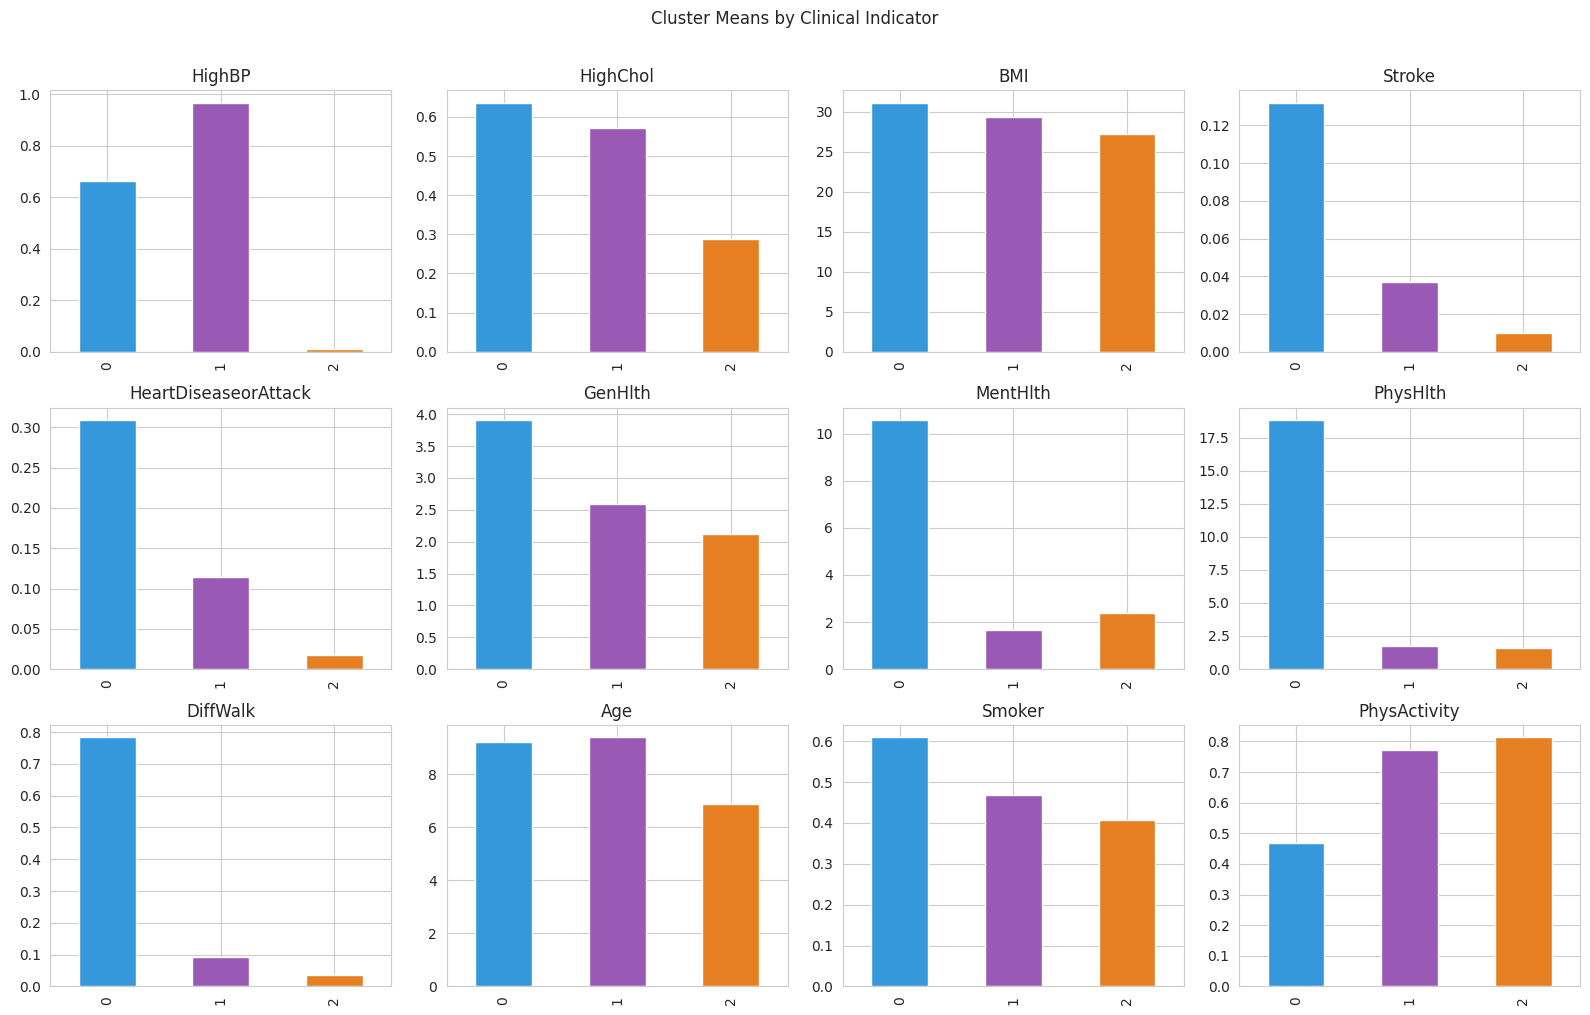

In [34]:
# Side-by-side bars for the headline clinical indicators
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flatten(), clinical_features):
    profile[col].plot(kind="bar", ax=ax, color=["#3498db", "#9b59b6", "#e67e22"])
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Cluster Means by Clinical Indicator", y=1.01)
plt.tight_layout()
plt.show()

In [35]:
# Name the clusters: sort by general health (1 = excellent .. 5 = poor)
risk_order = profile["GenHlth"].sort_values().index
risk_tiers = ["Low Risk", "Moderate Risk", "High Risk"]
cluster_risk = {int(c): risk_tiers[i] for i, c in enumerate(risk_order)}

print("Mean GenHlth per cluster (lower = healthier):")
print(profile["GenHlth"].round(2))
print()
print("Cluster -> risk tier:", cluster_risk)

Mean GenHlth per cluster (lower = healthier):
Cluster
0    3.91
1    2.59
2    2.13
Name: GenHlth, dtype: float64

Cluster -> risk tier: {2: 'Low Risk', 1: 'Moderate Risk', 0: 'High Risk'}


         No Diabetes %  Prediabetes %  Diabetes %  Diabetes+Pre %
Cluster                                                          
0                64.03           3.14       32.83           35.97
1                76.87           2.64       20.49           23.13
2                93.88           0.98        5.14            6.12


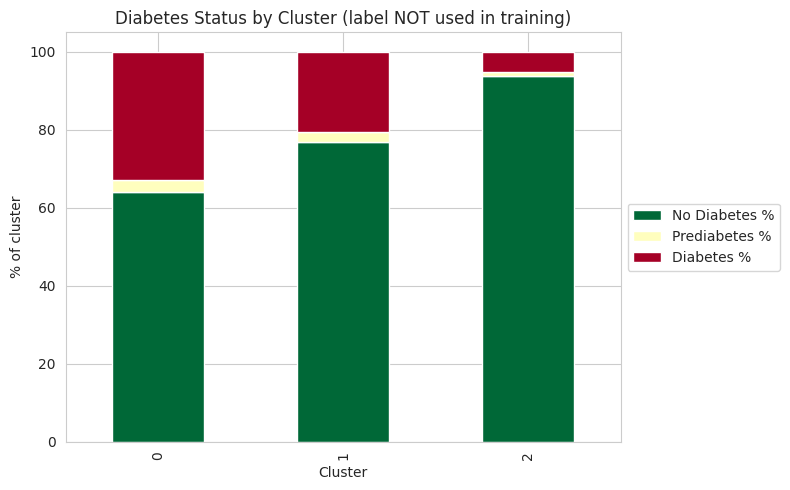

In [36]:
# Validate with the held-out label: diabetes prevalence per cluster
val = df.groupby("Cluster")["Diabetes_012"].value_counts(normalize=True).unstack() * 100
val.columns = ["No Diabetes %", "Prediabetes %", "Diabetes %"]
val["Diabetes+Pre %"] = val["Prediabetes %"] + val["Diabetes %"]
print(val.round(2))

val[["No Diabetes %", "Prediabetes %", "Diabetes %"]].plot(
    kind="bar", stacked=True, colormap="RdYlGn_r", figsize=(8, 5))
plt.title("Diabetes Status by Cluster (label NOT used in training)")
plt.ylabel("% of cluster")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

In [37]:
# Plain-language description of each cluster
for c in sorted(df["Cluster"].unique()):
    z = profile_z.loc[c]
    hi = z[z > 0.4].sort_values(ascending=False)
    lo = z[z < -0.4].sort_values()
    print(f"--- Cluster {c}  [{cluster_risk[c]}]  n={profile.loc[c, 'n_patients']:,} "
          f"({profile.loc[c, 'n_patients'] / len(df) * 100:.1f}%)")
    print(f"    Diabetes+Prediabetes: {val.loc[c, 'Diabetes+Pre %']:.1f}%")
    print(f"    Worse than average: {', '.join(f'{k} (+{v:.2f}sd)' for k, v in hi.items()) or 'none'}")
    print(f"    Better than average: {', '.join(f'{k} ({v:.2f}sd)' for k, v in lo.items()) or 'none'}")
    print()

--- Cluster 0  [High Risk]  n=1,721 (17.2%)
    Diabetes+Prediabetes: 36.0%
    Worse than average: PhysHlth (+1.57sd), DiffWalk (+1.55sd), GenHlth (+1.24sd), MentHlth (+0.90sd), HeartDiseaseorAttack (+0.69sd), Stroke (+0.47sd), HighBP (+0.43sd), BMI (+0.42sd)
    Better than average: PhysActivity (-0.62sd)

--- Cluster 1  [Moderate Risk]  n=3,377 (33.8%)
    Diabetes+Prediabetes: 23.1%
    Worse than average: HighBP (+1.05sd), Age (+0.41sd)
    Better than average: none

--- Cluster 2  [Low Risk]  n=4,902 (49.0%)
    Diabetes+Prediabetes: 6.1%
    Worse than average: none
    Better than average: HighBP (-0.87sd), GenHlth (-0.44sd), Age (-0.41sd)



### Reading the three segments

Cluster **ids** are arbitrary and change if the random seed changes — always read the **risk
tier**, never the id.

**Low Risk — "Healthy Younger Adults"** (~49% of patients, diabetes+prediabetes ~6%)

Almost no hypertension, lowest cholesterol, mean BMI ~27, hardly any cardiovascular history,
general health ~2.1 ("very good"), the youngest age buckets and the highest physical activity.
Below the population mean on every risk feature.

**Moderate Risk — "Metabolically Burdened, Functionally Intact"** (~34%, diabetes+prediabetes ~23%)

Hypertension is near-universal (~97%) with ~57% high cholesterol and mean BMI ~29. But
function is preserved: only ~9% report difficulty walking and poor-health days stay below the
population mean. Older, but still active.

**High Risk — "Multi-morbid, Functionally Limited"** (~17%, diabetes+prediabetes ~36%)

~31% cardiovascular disease, ~13% stroke history, mean BMI ~31, general health 3.9 ("fair"),
~19 poor physical-health days per month, and ~78% report difficulty walking. This is the
cluster where disease has already cost function.

**The clusters line up with the held-out label.** Diabetes+prediabetes rises monotonically
across the three tiers (6% -> 23% -> 36%) even though `Diabetes_012` was never shown to any
of the three algorithms. The segments are clinically real, not an artefact of the maths.

## 12. Final Conclusion

In [38]:
summary = pd.DataFrame({
    "Risk Tier": [cluster_risk[c] for c in sorted(cluster_risk)],
    "Patients": [profile.loc[c, "n_patients"] for c in sorted(cluster_risk)],
    "Share %": [round(profile.loc[c, "n_patients"] / len(df) * 100, 1) for c in sorted(cluster_risk)],
    "Diabetes+Pre %": [round(val.loc[c, "Diabetes+Pre %"], 1) for c in sorted(cluster_risk)],
    "Mean BMI": [profile.loc[c, "BMI"] for c in sorted(cluster_risk)],
    "HighBP %": [round(profile.loc[c, "HighBP"] * 100, 1) for c in sorted(cluster_risk)],
    "HighChol %": [round(profile.loc[c, "HighChol"] * 100, 1) for c in sorted(cluster_risk)],
    "CVD %": [round(profile.loc[c, "HeartDiseaseorAttack"] * 100, 1) for c in sorted(cluster_risk)],
    "DiffWalk %": [round(profile.loc[c, "DiffWalk"] * 100, 1) for c in sorted(cluster_risk)],
    "Mean GenHlth": [profile.loc[c, "GenHlth"] for c in sorted(cluster_risk)],
}, index=sorted(cluster_risk))
summary.index.name = "Cluster"
summary.to_csv("outputs/healthcare_insights.csv")
summary

,Risk Tier,Patients,Share %,Diabetes+Pre %,Mean BMI,HighBP %,HighChol %,CVD %,DiffWalk %,Mean GenHlth
Cluster,,,,,,,,,,
0,High Risk,1721,17.2,36.0,31.116,66.2,63.6,30.9,78.3,3.908
1,Moderate Risk,3377,33.8,23.1,29.312,96.7,57.1,11.4,9.2,2.589
2,Low Risk,4902,49.0,6.1,27.155,1.1,28.9,1.8,3.6,2.126


### Conclusion

**What was done.** 10,000 BRFSS 2015 respondents were cleaned (duplicates removed, BMI capped
at the 1st/99th percentile), reduced to 12 clinical indicators, standardized, and clustered
with three algorithms — K-Means (k from the elbow), Hierarchical/Ward (k from the dendrogram),
and DBSCAN (eps from the k-distance graph). All three were scored with Silhouette on identical
data.

**What was chosen.** K-Means with k = 3. Hierarchical scored higher on Silhouette (0.249 vs
0.142) but put 72% of patients in one cluster; DBSCAN (0.226) put 74% in one cluster plus 566
noise points. K-Means produced three balanced, usable segments and is the only one of the three
that can assign a new patient.

**What it found.** Three risk tiers — Low (~49%), Moderate (~34%), High (~17%). Diabetes +
prediabetes prevalence rises 6% -> 23% -> 36% across them, and the label was never used in
training, so the tiers carry real clinical signal.

**What it is useful for.** Every feature comes from a survey or routine vitals — no HbA1c, no
blood draw. A clinic can tier its whole patient panel from intake data and send confirmatory
testing to the High Risk tier first. The Moderate tier is the intervention target: it carries
the full metabolic load but has not yet lost function, so lifestyle and drug therapy can still
change its trajectory.

**Limitations.** BRFSS is self-reported, so conditions are under-reported and BMI comes from
self-reported height and weight. The data is cross-sectional, so nothing here is causal.
Silhouette values are modest because health risk is a continuum rather than well-separated
groups — the output is useful risk *strata*, not natural kinds. `Age` is bucketed (1-13), not
exact years. Cluster ids permute between runs; key on the risk tier.

### Save artifacts for the Streamlit app

In [39]:
joblib.dump(kmeans, "models/kmeans_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(pca, "models/pca.pkl")

meta = {
    "clinical_features": clinical_features,
    "best_k": BEST_K,
    "cluster_risk": {str(k): v for k, v in cluster_risk.items()},
    "bmi_cap": [float(p01), float(p99)],
    "n_patients": int(len(df)),
    "metrics": {"silhouette": float(silhouette_score(X_scaled, final_labels))},
    "algorithms": {
        "kmeans": {"k": BEST_K, "silhouette": float(silhouette_score(X_scaled, km_labels))},
        "hierarchical": {"k": 3, "silhouette": float(silhouette_score(X_scaled, hc_labels))},
        "dbscan": {"eps": EPS, "min_samples": MIN_SAMPLES,
                   "n_clusters": int(n_db_clusters), "noise": int(n_noise),
                   "silhouette": float(silhouette_score(X_scaled, db_labels))},
    },
    "feature_ranges": {c: [float(X[c].min()), float(X[c].max())] for c in clinical_features},
    "population_mean": {c: float(X[c].mean()) for c in clinical_features},
    "population_std": {c: float(X[c].std()) for c in clinical_features},
}

with open("models/metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

profile.to_csv("models/cluster_profiles.csv")
profile_z.round(4).to_csv("models/cluster_profiles_z.csv")
val.round(2).to_csv("models/cluster_validation.csv")
scores.to_csv("models/evaluation_scores.csv")
comparison.to_csv("models/algorithm_comparison.csv", index=False)

# Clustered patients with PCA coords, for the app's scatter plot
out = df.copy()
out["PC1"] = coords[:, 0]
out["PC2"] = coords[:, 1]
out.to_csv("models/clustered_sample.csv", index=False)

print("Saved:", sorted(os.listdir("models")))

Saved: ['algorithm_comparison.csv', 'cluster_profiles.csv', 'cluster_profiles_z.csv', 'cluster_validation.csv', 'clustered_sample.csv', 'evaluation_scores.csv', 'kmeans_model.pkl', 'metadata.json', 'pca.pkl', 'scaler.pkl']


In [40]:
# Round-trip check: reload the saved model and re-assign one patient
m = joblib.load("models/kmeans_model.pkl")
s = joblib.load("models/scaler.pkl")

pred = m.predict(s.transform(X.iloc[[0]]))[0]
assert pred == df.loc[0, "Cluster"], "Reloaded model disagrees with training labels"

print("Round-trip OK. Patient 0 ->", f"Cluster {pred} ({cluster_risk[pred]})")
print()
print("Pipeline complete.")

Round-trip OK. Patient 0 -> Cluster 0 (High Risk)

Pipeline complete.
